# [DAS509] 4강 Python Pandas를 활용한 데이터 정제와 가공

- 데이터분석에서 데이터를 불러오고 정제하고 변형하여 분석이 가능한 형태로 준비하는 일은 매우 많은 시간을 필요로 함
- Pandas 패키지를 활용하면 데이터 정제와 가공 작업을 손쉽게 할 수 있음

### 1. 하나의 데이터 다루기 (Handling A Single Data Set)

### 1.1. 결측치

- 불러온 데이터에 종종 결측값이 발생

### 결측치 확인하기

- Pandas에서는 기본적으로 결측치를 제거하고 연산을 수행

In [84]:
# 수치형 자료
float_data = pd.Series([1.2, -3.5, np.nan, 0])
float_data
float_data.isna()

0    False
1    False
2     True
3    False
dtype: bool

- 결측치 삭제하기

In [36]:
data = pd.Series([1, np.nan, 3.5, np.nan, 7])
data.dropna()

# or equivalently
data[data.notna()]

0    1.0
2    3.5
4    7.0
dtype: float64

- 데이터프레임에서는 결측지가 하나라도 있으면 제외함

In [ ]:
data = pd.DataFrame([[1., 6.5, 3.], [1., np.nan, np.nan],
                     [np.nan, np.nan, np.nan], [np.nan, 6.5, 3.]])
data
data.dropna()

- 모든 값이 결측인 경우에만 제외하고 싶다면?

In [ ]:
data.dropna(how = "all")

- 결측치가 특정 개수보다 적은 행만 보고 싶다면?

In [ ]:
df = pd.DataFrame(np.random.standard_normal((7, 3)))
df.iloc[:4, 1] = np.nan
df.iloc[:2, 2] = np.nan
df
df.dropna()
df.dropna(thresh=2)

- 행이 아닌 열을 기준으로 결측치를 제거하고 싶다면?

In [ ]:
df.dropna(axis = "columns")

### 결측치 채우기

- fillna 함수를 활용하여 결측치를 원하는 값을 채워넣을 수 있음

In [ ]:
df.fillna(0)

# 열별로 다른 값으로 채워넣을 수도 있음
df.fillna({1: 0.5, 2: 0}) 

# 뒤의 값을 앞에 채워넣음
df.fillna(method="bfill") # ffill은 앞의 값을 뒤에 채워넣음

# 채워넣는 개체의 limit을 설정할 수 있음
df.fillna(method="bfill", limit=2)

# 각 열의 평균을 채워넣음
df.fillna(df.mean())

## 1.2. 값의 치환

- 결측치를 채우는 작업은 값의 치환 작업이라 볼 수 있음
- replace 함수를 통해 값의 치환을 간단하게 할 수 있음

In [ ]:
df = pd.DataFrame({'A': [0, 1, 2, 3, 4],
                   'B': [5, 6, 7, 8, 9],
                   'C': ['a', 'b', 'c', 'd', 'e']})

df
df.replace(0, 5) # value to value
df.replace([0, 1, 2, 3], 4) # list to value
df.replace([0, 1, 2, 3], [4, 3, 2, 1]) # list to list

## 1.3. 중복된 값

- 중복된 행이 종종 발생할 수 있으며, duplicated 함수를 통해 이를 확인할 수 있음

In [ ]:
data = pd.DataFrame({"k1": ["one", "two"] * 3 + ["two"],
                     "k2": [1, 1, 2, 3, 3, 4, 4]})
data

data.duplicated()

- 삭제하고 싶다면?

In [ ]:
data.drop_duplicates()

## 1.4. 이상치 (Outlier) 탐색

- 데이터 분석에서 이상치 / 특이값을 확인하는 것은 중요함
- 아래의 예제 데이터에서 절대값이 3을 초과하는 값을 찾아보자.

In [89]:
data = pd.DataFrame(np.random.standard_normal((1000, 4)))
data.describe()

# 3번째 열에서 이상치 찾기
col = data[2]
col[col.abs() > 3]

# 이상치가 하나라도 있는 관측치 (행) 찾기
data[(data.abs() > 3).any(axis="columns")]

,0,1,2,3
138,-1.971042,0.936085,-0.749193,-3.251923
312,0.005876,1.593799,3.075830,-1.988752
392,1.493779,-0.184186,3.249802,-0.460276
405,1.326164,-3.081183,0.879605,0.335546
460,3.116075,-0.053183,-1.429761,-0.481143
...,...,...,...,...
750,1.692958,-3.533435,-1.517563,0.864716
788,0.961663,-0.640863,3.168587,-0.822202
796,-3.081625,0.239169,-0.435759,0.556803
932,3.019100,-0.966724,0.231926,0.581443


- 절대값이 3을 초과하는 이상치를 -3이나 3으로 바꿔보자

In [90]:
data[data.abs() > 3] = np.sign(data) * 3
data.describe()

,0,1,2,3
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,-0.028684,-0.030494,0.016922,0.040650
std,0.975560,0.988161,1.002048,1.016027
min,-3.000000,-3.000000,-2.544032,-3.000000
25%,-0.665502,-0.699808,-0.690040,-0.635088
50%,0.021575,-0.033368,0.038479,0.072272
75%,0.602609,0.646315,0.678254,0.729212
max,3.000000,3.000000,3.000000,3.000000


## 1.5. 임의화

- 기계학습에서 임의화는 매우 중요한 역할을 함
    - Cross-Validation
    - Bootstrap / Subsampling
- numpy.random.permutation 함수를 이용하면 데이터의 행을 임의로 재배치할 수 있음

In [92]:
v = np.arange(5 * 7).reshape((5,7))
df = pd.DataFrame(v)
df

,0,1,2,3,4,5,6
0,0,1,2,3,4,5,6
1,7,8,9,10,11,12,13
2,14,15,16,17,18,19,20
3,21,22,23,24,25,26,27
4,28,29,30,31,32,33,34


- Row Permutation (Default)

In [93]:
sampler = np.random.permutation(5)
sampler

df.take(sampler)
# or equivaletly
df.iloc[sampler]

,0,1,2,3,4,5,6
0,0,1,2,3,4,5,6
3,21,22,23,24,25,26,27
4,28,29,30,31,32,33,34
1,7,8,9,10,11,12,13
2,14,15,16,17,18,19,20


- Column Permutation

In [94]:
column_sampler = np.random.permutation(7)
column_sampler

df.iloc[:,column_sampler]
# or equivaletly
df.take(column_sampler, axis="columns")

,5,0,1,4,2,6,3
0,5,0,1,4,2,6,3
1,12,7,8,11,9,13,10
2,19,14,15,18,16,20,17
3,26,21,22,25,23,27,24
4,33,28,29,32,30,34,31


- Subsampling

In [95]:
df.sample(n=3)

,0,1,2,3,4,5,6
2,14,15,16,17,18,19,20
0,0,1,2,3,4,5,6
3,21,22,23,24,25,26,27


- Bootstrapping (Sampling with Replacement)

In [96]:
df.sample(n = len(df), replace = True)

,0,1,2,3,4,5,6
1,7,8,9,10,11,12,13
4,28,29,30,31,32,33,34
0,0,1,2,3,4,5,6
0,0,1,2,3,4,5,6
4,28,29,30,31,32,33,34


## 1.6 더미(Dummy) 변수화

- 범주형 자료를 분석하기 위해서는 종종 더미변수를 활용

In [97]:
df = pd.DataFrame({"key": ["b", "b", "a", "c", "a", "b"],
                   "value": range(6)})
df

,key,value
0,b,0
1,b,1
2,a,2
3,c,3
4,a,4
5,b,5


- 판다에서는 pandas.get_dummies 함수를 제공

In [98]:
# Get Dummies
dummies = pd.get_dummies(df["key"], prefix="key", dtype=float)
dummies

# Combine data sets
df_with_dummy = df[["value"]].join(dummies) # join 함수 활용
df_with_dummy

,value,key_a,key_b,key_c
0,0,0.0,1.0,0.0
1,1,0.0,1.0,0.0
2,2,1.0,0.0,0.0
3,3,0.0,0.0,1.0
4,4,1.0,0.0,0.0
5,5,0.0,1.0,0.0


- pandas.cut과 함께 사용하면 연속형 변수를 범주화하여 모델링에 활용하는데 유용

In [99]:
np.random.seed(12345) # to make the example repeatable
values = np.random.uniform(size=10)
values
bins = [0, 0.2, 0.4, 0.6, 0.8, 1]
pd.get_dummies(pd.cut(values, bins))

,"(0.0, 0.2]","(0.2, 0.4]","(0.4, 0.6]","(0.6, 0.8]","(0.8, 1.0]"
0,False,False,False,False,True
1,False,True,False,False,False
2,True,False,False,False,False
3,False,True,False,False,False
4,False,False,True,False,False
5,False,False,True,False,False
6,False,False,False,False,True
7,False,False,False,True,False
8,False,False,False,True,False
9,False,False,False,True,False


## 1.7. 계층적 색인 (Hierarchical Indexing)

- 둘 이상의 색인 단계를 지정할 수 있음
- 고차원 자료를 2차원으로 표현할 수 있게 함
- Series를 예로 살펴보면

In [100]:
data = pd.Series(np.random.uniform(size=9),
                 index=[["a", "a", "a", "b", "b", "c", "c", "d", "d"],
                        [1, 2, 3, 1, 3, 1, 2, 2, 3]])
data
data.index # 인덱스 확인

MultiIndex([('a', 1),
            ('a', 2),
            ('a', 3),
            ('b', 1),
            ('b', 3),
            ('c', 1),
            ('c', 2),
            ('d', 2),
            ('d', 3)],
           )

- 인덱스를 통해 데이터의 일부분을 쉽게 확인 가능

In [101]:
# 1st level index
data["b"]
data["b":"c"]
data.loc[["b", "d"]]

# 2nd level index
data.loc[:, 2]

a    0.961307
c    0.809813
d    0.872176
dtype: float64

- Table 생성 (Compact Form)

In [102]:
data.unstack()
data.unstack().stack()

a  1    0.747715
   2    0.961307
   3    0.008388
b  1    0.106444
   3    0.298704
c  1    0.656411
   2    0.809813
d  2    0.872176
   3    0.964648
dtype: float64

- 행과 열 모두 Hierarchical Index를 가질 수있음

In [103]:
frame = pd.DataFrame(np.arange(12).reshape((4, 3)),
                     index=[["a", "a", "b", "b"], [1, 2, 1, 2]],
                     columns=[["Ohio", "Ohio", "Colorado"],
                              ["Green", "Red", "Green"]])
frame

Ohio     Colorado
    Green Red    Green
a 1     0   1        2
  2     3   4        5
b 1     6   7        8
  2     9  10       11

- 각 계층에 이름을 설정할 수 있음

In [109]:
frame.index.names = ["key1", "key2"]
frame.columns.names = ["state", "color"]
frame

state      Ohio     Colorado
color     Green Red    Green
key1 key2                   
a    1        0   1        2
     2        3   4        5
b    1        6   7        8
     2        9  10       11

- 색인이 몇개의 계층을 가지는지 확인 가능

In [110]:
frame.index.nlevels

2

- 접근방식은 일반적 색인과 동일

In [107]:
frame["Ohio"]

Green  Red
a 1      0    1
  2      3    4
b 1      6    7
  2      9   10

- 계층의 순서를 바꿀 수 있음

In [111]:
frame.swaplevel("key1", "key2")

state      Ohio     Colorado
color     Green Red    Green
key2 key1                   
1    a        0   1        2
2    a        3   4        5
1    b        6   7        8
2    b        9  10       11

- 정렬도 가능

In [112]:
frame.sort_index(level=1) # 두번째 색인에 대해서 정렬
frame.swaplevel(0, 1).sort_index(level=0) # 색인을 바꾼뒤 첫번째 색인에 대해 정렬

state      Ohio     Colorado
color     Green Red    Green
key2 key1                   
1    a        0   1        2
     b        6   7        8
2    a        3   4        5
     b        9  10       11

- 특정 열을 색인으로 옮길 수 있음

In [113]:
frame = pd.DataFrame({"a": range(7), "b": range(7, 0, -1),
                      "c": ["one", "one", "one", "two", "two",
                            "two", "two"],
                      "d": [0, 1, 2, 0, 1, 2, 3]})
frame

frame2 = frame.set_index(["c", "d"])
frame2

a  b
c   d      
one 0  0  7
    1  1  6
    2  2  5
two 0  3  4
    1  4  3
    2  5  2
    3  6  1

- 색인으로 사용된 열은 자동으로 사라지지만 drop 옵션을 통해 그대로 유지할 수도 있음

In [114]:
frame.set_index(["c", "d"], drop=False)

a  b    c  d
c   d              
one 0  0  7  one  0
    1  1  6  one  1
    2  2  5  one  2
two 0  3  4  two  0
    1  4  3  two  1
    2  5  2  two  2
    3  6  1  two  3

- reset_index함수는 set_index함수의 반대연산 (색인 → 열)

In [116]:
frame2.reset_index()

,c,d,a,b
0,one,0,0,7
1,one,1,1,6
2,one,2,2,5
3,two,0,3,4
4,two,1,4,3
5,two,2,5,2
6,two,3,6,1


# 2. 범주형 객체

## 2.1 소개

- 범주형 데이터는 그 특성상 유사한 값이 다수 존재하므로, 효율적으로 정리하면 빠른 성능을 보일 수 있음
- 정수 기반의 범주형 데이터를 표현하는 데이터 유형인 Categorical이 있음

In [117]:
fruits = ['apple', 'orange', 'apple', 'apple'] * 2
N = len(fruits)
rng = np.random.default_rng(seed=12345)
df = pd.DataFrame({'fruit': fruits,
                   'basket_id': np.arange(N),
                   'count': rng.integers(3, 15, size=N),
                   'weight': rng.uniform(0, 4, size=N)},
                  columns=['basket_id', 'fruit', 'count', 'weight'])
df

,basket_id,fruit,count,weight
0,0,apple,11,1.564438
1,1,orange,5,1.331256
2,2,apple,12,2.393235
3,3,apple,6,0.746937
4,4,apple,5,2.691024
5,5,orange,12,3.767211
6,6,apple,10,0.992983
7,7,apple,11,3.795525


- astype()함수를 이용하여 범주형 데이터로 변경

In [118]:
fruit_cat = df['fruit'].astype('category')
fruit_cat
fruit_cat.info()

<class 'pandas.core.series.Series'>
RangeIndex: 8 entries, 0 to 7
Series name: fruit
Non-Null Count  Dtype   
--------------  -----   
8 non-null      category
dtypes: category(1)
memory usage: 264.0 bytes


- categories (범주의 label)과 codes (label을 정수로 맵핑한 값) 속성으로 구성되어 있음

In [119]:
c = fruit_cat.array
c.categories
c.codes

array([0, 1, 0, 0, 0, 1, 0, 0], dtype=int8)

- 범주와 코드간의 맵핑의 정보를 확인하려면

In [120]:
dict(enumerate(c.categories))

{0: 'apple', 1: 'orange'}

- Categorical 객체를 직접 생성할수도 있고

In [121]:
my_cats1 = pd.Categorical(['foo', 'bar', 'baz', 'foo', 'foo', 'bar'])
my_cats1

['foo', 'bar', 'baz', 'foo', 'foo', 'bar']
Categories (3, object): ['bar', 'baz', 'foo']

- 기존에 정의된 categories와 codes가 있으면 from_codes로도 생성 가능

In [122]:
categories = ['foo', 'bar', 'baz']
codes = [0, 1, 2, 0, 0, 1]
my_cats2 = pd.Categorical.from_codes(codes, categories)
my_cats2

['foo', 'bar', 'baz', 'foo', 'foo', 'bar']
Categories (3, object): ['foo', 'bar', 'baz']

- label의 순서를 원하는 대로 지정할 수 있으며,

In [123]:
my_cats2.reorder_categories(['baz', 'foo', 'bar'])

['foo', 'bar', 'baz', 'foo', 'foo', 'bar']
Categories (3, object): ['baz', 'foo', 'bar']

- 범주에 순서를 부여가능

In [124]:
my_cats2.as_ordered()

['foo', 'bar', 'baz', 'foo', 'foo', 'bar']
Categories (3, object): ['foo' < 'bar' < 'baz']

## 2.2 연속형 변수의 범주화

- 연속형 변수를 이산형 변수로 바꾸는 경우 pandas.cut 함수를 활용

In [125]:
ages = [20, 22, 25, 27, 21, 23, 37, 31, 61, 45, 41, 32]
bins = [18, 25, 35, 60, 100]
age_categories = pd.cut(ages, bins)
age_categories

[(18, 25], (18, 25], (18, 25], (25, 35], (18, 25], ..., (25, 35], (60, 100], (35, 60], (35, 60], (25, 35]]
Length: 12
Categories (4, interval[int64, right]): [(18, 25] < (25, 35] < (35, 60] < (60, 100]]

- age_categories는 Categorical 객체

In [126]:
age_categories.codes
age_categories.categories


IntervalIndex([(18, 25], (25, 35], (35, 60], (60, 100]], dtype='interval[int64, right]')

- 이산형 변수에 레이블 할당 가능

In [127]:
group_names = ["Youth", "YoungAdult", "MiddleAged", "Senior"]
pd.cut(ages, bins, labels=group_names)

['Youth', 'Youth', 'Youth', 'YoungAdult', 'Youth', ..., 'YoungAdult', 'Senior', 'MiddleAged', 'MiddleAged', 'YoungAdult']
Length: 12
Categories (4, object): ['Youth' < 'YoungAdult' < 'MiddleAged' < 'Senior']

- 범주간의 경계값 대신 갯수를 지정할 수 있음 (최소값과 최대값을 기준으로 균등한 길이로 구간을 분할)

In [128]:
data = np.random.uniform(size=20)
pd.cut(data, 4, precision=2) # 소수점 아래 2자리

[(0.51, 0.75], (0.51, 0.75], (0.51, 0.75], (0.27, 0.51], (0.27, 0.51], ..., (0.27, 0.51], (0.51, 0.75], (0.51, 0.75], (0.024, 0.27], (0.75, 0.99]]
Length: 20
Categories (4, interval[float64, right]): [(0.024, 0.27] < (0.27, 0.51] < (0.51, 0.75] < (0.75, 0.99]]

- pandas.qcut: 4분위수 (Quartile) 기준으로 나누는 함수

In [129]:
data = np.random.standard_normal(1000)
quartiles = pd.qcut(data, 4, precision=2)
quartiles
pd.value_counts(quartiles)

C:\Users\jjw94\AppData\Local\Temp\ipykernel_2196\3037377620.py:4: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(quartiles)


(-3.6799999999999997, -0.65]    250
(-0.65, 0.037]                  250
(0.037, 0.65]                   250
(0.65, 3.85]                    250
Name: count, dtype: int64

- 분위수를 자유롭게 설정할 수 있음

In [130]:
percentiles = pd.qcut(data, [0, 0.1, 0.25, 0.4, 0.5, 0.8, 0.9, 1.])
ftb = pd.value_counts(percentiles)
ftb.sort_index()

C:\Users\jjw94\AppData\Local\Temp\ipykernel_2196\420034162.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  ftb = pd.value_counts(percentiles)


(-3.6719999999999997, -1.253]    100
(-1.253, -0.648]                 150
(-0.648, -0.243]                 150
(-0.243, 0.0369]                 100
(0.0369, 0.861]                  300
(0.861, 1.312]                   100
(1.312, 3.853]                   100
Name: count, dtype: int64

## 2.3 연산

- 일반 문자열 변수보다 groupby 같은 함수를 적용할 때 더 나은 성능을 보임
- pandas.cut함수를 활용하면 연속형 변수를 범주형 변수로 손쉽게 변환할 수 있음

In [131]:
rng = np.random.default_rng(seed=12345)
draws = rng.standard_normal(1000)
bins = pd.qcut(draws, 4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
bins
bins.codes
bins.categories

Index(['Q1', 'Q2', 'Q3', 'Q4'], dtype='object')

- groupby를 이용하여 분위수별 통계량을 계산

In [132]:
bins = pd.Series(bins, name='quartile')
g_draws = pd.Series(draws).groupby(bins)
result = g_draws.agg(['count', 'min', 'max'])
result

C:\Users\jjw94\AppData\Local\Temp\ipykernel_2196\1559933211.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g_draws = pd.Series(draws).groupby(bins)


,count,min,max
quartile,,,
Q1,250,-3.119609,-0.678494
Q2,250,-0.673305,0.008009
Q3,250,0.018753,0.686183
Q4,250,0.688282,3.211418


- 계산 효율성 비교 1 - 메모리

In [133]:
N = 10000000
labels = pd.Series(['foo', 'bar', 'baz', 'qux'] * (N // 4))
categories = labels.astype('category')
labels.memory_usage(deep=True)     # string
categories.memory_usage(deep=True) # cetegory

10000544

- 계산 효율성 비교 2 - 계산 속도

In [134]:
%timeit labels.value_counts()
%timeit categories.value_counts()

413 ms ± 25.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
42 ms ± 1.16 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


## 2.4 Categorical 관련 함수

- frequency

In [135]:
s = pd.Series(['a', 'b', 'c', 'd'] * 2)
cat_s = s.astype('category')
cat_s
cat_s.value_counts()

a    2
b    2
c    2
d    2
Name: count, dtype: int64

- 새로운 범주 설정

In [136]:
cat_s2 = cat_s.cat.add_categories('e')
cat_s2.value_counts()

a    2
b    2
c    2
d    2
e    0
Name: count, dtype: int64

- 사용하지 않는 범주의 삭제

In [137]:
cat_s3 = cat_s[cat_s.isin(['a', 'b'])]
cat_s3
cat_s3.cat.remove_unused_categories()

0    a
1    b
4    a
5    b
dtype: category
Categories (2, object): ['a', 'b']

- 주요 함수들을 정리하면,

| 함수 (method) | 설명 |
| --- | --- |
| add_categories | 기존 범주의 끝에 새로운 카테고리를 추가 |
| as_ordered | 순서를 부여 |
| as_unordered | 순서를 제거 |
| remove_categories | 범주를 제거하고, 해당 범주의 값은 null로 변환 |
| remove_unused_categories | 데이터에서 관측되지 않는 범주를 삭제 |
| rename_categories | 범주의 이름을 변경 |
| reorder_categories | 범주이름의 순서를 변경함과 동시에 순서의 의미를 부여 |
| set_categories | 새로운 범주로 변경, 추가, 삭제 |

# 3. 여러 개의 데이터 다루기 (Handling Relational Data)

- Pandas에서 데이터를 합치는 방법
    - pandas.merge: 하나 이상의 키를 기준으로 DataFrame의 행을 연결 (SQL의 Join과 유사)
    - DataFrame.join: 인덱스를 기준으로 merge와 동일한 기능 수행
    - pandas.concat: 하나의 축을 따라서 객체를 이어 붙임
    - combine_first: 두객체를 합쳐서 한 객체에서 누락된 데이터를 다른 객체에 있는 값으로 채움

## 3.1 Merge

- 관계형 데이터베이스의 핵심 연산으로 하나 이상의 키를 사용하여 데이터의 행을 병합

In [138]:
# 예제 (다대일 병합)
df1 = pd.DataFrame({"key": ["b", "b", "a", "c", "a", "a", "b"],
                    "data1": pd.Series(range(7), dtype="Int64")})
df2 = pd.DataFrame({"key": ["a", "b", "d"],
                    "data2": pd.Series(range(3), dtype="Int64")})
df1
df2

,key,data2
0,a,0
1,b,1
2,d,2


- pd.merge함수를 이용해 데이터를 병합해 보자.

In [139]:
pd.merge(df1, df2)
# or 
pd.merge(df1, df2, on = "key") # This is better! (병합의 기준 명시)

,key,data1,data2
0,b,0,1
1,b,1,1
2,a,2,0
3,a,4,0
4,a,5,0
5,b,6,1


- 두 데이터에 저장된 key가 서로 다른 값으로 지정되어 있는 경우

In [140]:
df3 = pd.DataFrame({"lkey": ["b", "b", "a", "c", "a", "a", "b"],
                    "data1": pd.Series(range(7), dtype="Int64")})
df4 = pd.DataFrame({"rkey": ["a", "b", "d"],
                    "data2": pd.Series(range(3), dtype="Int64")})

pd.merge(df3, df4, left_on="lkey", right_on="rkey")

,lkey,data1,rkey,data2
0,b,0,b,1
1,b,1,b,1
2,a,2,a,0
3,a,4,a,0
4,a,5,a,0
5,b,6,b,1


- merge 방법

- 내부 조인 (inner join): how = “inner”

In [141]:
pd.merge(df1, df2) # or 
pd.merge(df1, df2, how = "inner")

,key,data1,data2
0,b,0,1
1,b,1,1
2,a,2,0
3,a,4,0
4,a,5,0
5,b,6,1


- 좌측 조인 (left join): how = “left”

In [142]:
pd.merge(df1, df2, how="left")

,key,data1,data2
0,b,0,1
1,b,1,1
2,a,2,0
3,c,3,<NA>
4,a,4,0
5,a,5,0
6,b,6,1


- 우측 조인 (right join): how = “right”

In [143]:
pd.merge(df1, df2, how="right")

,key,data1,data2
0,a,2,0
1,a,4,0
2,a,5,0
3,b,0,1
4,b,1,1
5,b,6,1
6,d,<NA>,2


- 외부 조인 (outer join): how = “outer”

In [145]:
pd.merge(df1, df2, how = "outer")

,key,data1,data2
0,a,2,0
1,a,4,0
2,a,5,0
3,b,0,1
4,b,1,1
5,b,6,1
6,c,3,<NA>
7,d,<NA>,2


- 다대다 (many-to-many) 병합은 일치하는 키에 대한 모든 경우를 고려함

In [146]:
df1 = pd.DataFrame({"key": ["b", "b", "a", "c", "a", "b"],
                    "data1": pd.Series(range(6), dtype="Int64")})
df1

df2 = pd.DataFrame({"key": ["a", "b", "a", "b", "d"],
                    "data2": pd.Series(range(5), dtype="Int64")})
df2
pd.merge(df1, df2, on="key", how="left")
pd.merge(df1, df2, how="inner")

,key,data1,data2
0,b,0,1
1,b,0,3
2,b,1,1
3,b,1,3
4,a,2,0
5,a,2,2
6,a,4,0
7,a,4,2
8,b,5,1
9,b,5,3


- 여러개의 키를 병합하기 위해서는 열 이름이 담긴 리스트를 넘김

In [147]:
left = pd.DataFrame({"key1": ["foo", "foo", "bar"],
                     "key2": ["one", "two", "one"],
                     "lval": pd.Series([1, 2, 3], dtype='Int64')})
right = pd.DataFrame({"key1": ["foo", "foo", "bar", "bar"],
                      "key2": ["one", "one", "one", "two"],
                      "rval": pd.Series([4, 5, 6, 7], dtype='Int64')})
pd.merge(left, right, on=["key1", "key2"], how="outer")

,key1,key2,lval,rval
0,bar,one,3,6
1,bar,two,<NA>,7
2,foo,one,1,4
3,foo,one,1,5
4,foo,two,2,<NA>


- 병합하려는 키가 DataFrame의 index인 경우
    - left_index / right_index 옵션 사용

In [148]:
left1 = pd.DataFrame({"key": ["a", "b", "a", "a", "b", "c"],
                      "value": pd.Series(range(6), dtype="Int64")})
left1

right1 = pd.DataFrame({"group_val": [3.5, 7]}, index=["a", "b"])
right1

pd.merge(left1, right1, left_on="key", right_index=True)
pd.merge(left1, right1, left_on="key", right_index=True, how="outer")

,key,value,group_val
0,a,0,3.5
2,a,2,3.5
3,a,3,3.5
1,b,1,7.0
4,b,4,7.0
5,c,5,NaN


- 계층적 색인으로 된 데이터도 병합가능 (물론 좀더 복잡)

In [149]:
# left data
lefth = pd.DataFrame({"key1": ["Ohio", "Ohio", "Ohio",
                               "Nevada", "Nevada"],
                      "key2": [2000, 2001, 2002, 2001, 2002],
                      "data": pd.Series(range(5), dtype="Int64")})

# index object for the right data
righth_index = pd.MultiIndex.from_arrays(
    [
        ["Nevada", "Nevada", "Ohio", "Ohio", "Ohio", "Ohio"],
        [2001, 2000, 2000, 2000, 2001, 2002]
    ]
)
# right data
righth = pd.DataFrame({"event1": pd.Series([0, 2, 4, 6, 8, 10], dtype="Int64",
                                           index=righth_index),
                       "event2": pd.Series([1, 3, 5, 7, 9, 11], dtype="Int64",
                                           index=righth_index)})
lefth
righth

event1  event2
Nevada 2001       0       1
       2000       2       3
Ohio   2000       4       5
       2000       6       7
       2001       8       9
       2002      10      11

In [150]:
pd.merge(lefth, righth, left_on=["key1", "key2"], right_index=True)
pd.merge(lefth, righth, left_on=["key1", "key2"],
         right_index=True, how="outer")

,key1,key2,data,event1,event2
4,Nevada,2000,<NA>,2,3
3,Nevada,2001,3,0,1
4,Nevada,2002,4,<NA>,<NA>
0,Ohio,2000,0,4,5
0,Ohio,2000,0,6,7
1,Ohio,2001,1,8,9
2,Ohio,2002,2,10,11


- 색인끼리 병합도 가능 (left_index / right_index를 모두 활용)

In [151]:
left2 = pd.DataFrame([[1., 2.], [3., 4.], [5., 6.]],
                     index=["a", "c", "e"],
                     columns=["Ohio", "Nevada"]).astype("Int64")
left2
right2 = pd.DataFrame([[7., 8.], [9., 10.], [11., 12.], [13, 14]],
                      index=["b", "c", "d", "e"],
                      columns=["Missouri", "Alabama"]).astype("Int64")
right2
pd.merge(left2, right2, how="outer", left_index=True, right_index=True)

,Ohio,Nevada,Missouri,Alabama
a,1,2,<NA>,<NA>
b,<NA>,<NA>,7,8
c,3,4,9,10
d,<NA>,<NA>,11,12
e,5,6,13,14


## 3.2 Join

- 완전히 같거나 유사한 Index 구조를 가진 여러개의 DataFrame을 병합할 때 사용
- join 메서드를 호출한 객체에 (index를 기준으로) 데이터를 연결한다고 생각할 수 있음

In [152]:
left2.join(right2, how = "outer")

,Ohio,Nevada,Missouri,Alabama
a,1,2,<NA>,<NA>
b,<NA>,<NA>,7,8
c,3,4,9,10
d,<NA>,<NA>,11,12
e,5,6,13,14


- 한쪽은 색인이 아닌 열에 key값이 있는 경우

In [153]:
left1.join(right1, on = "key")

,key,value,group_val
0,a,0,3.5
1,b,1,7.0
2,a,2,3.5
3,a,3,3.5
4,b,4,7.0
5,c,5,NaN


## 3.3 축에 따라 이어 붙이기 (Concatenation / Stacking)

- Numpy에서는 ndarray를 연결하는 concatenate 함수를 제공
- Pandas 객체도 유사한 방식으로 쉽게 가져다 붙일 수 있으나 다음을 고려해야함
    - 연결하려는 객체의 색인이 서로 다르면?
    - 합쳐진 객체에서 합쳐지기 이전의 데이터를 구분할 수 있는가?
    - 어떤 축으로 연결할 것인지 고려해야하는가?
- pandas.concat 함수를 활용하면 됨
- 먼저 간단한 구조인 Series를 살펴보자.

In [154]:
s1 = pd.Series([0, 1], index=["a", "b"], dtype="Int64")
s1
s2 = pd.Series([2, 3, 4], index=["c", "d", "e"], dtype="Int64")
s2
s3 = pd.Series([5, 6], index=["f", "g"], dtype="Int64")
s3

f    5
g    6
dtype: Int64

- 간단히 합쳐보자.

In [155]:
pd.concat([s1, s2, s3])

a    0
b    1
c    2
d    3
e    4
f    5
g    6
dtype: Int64

- 기본값으로 index 방향으로 결합하지만 column 방향으로도 가능

In [156]:
pd.concat([s1, s2, s3], axis="columns")

,0,1,2
a,0,<NA>,<NA>
b,1,<NA>,<NA>
c,<NA>,2,<NA>
d,<NA>,3,<NA>
e,<NA>,4,<NA>
f,<NA>,<NA>,5
g,<NA>,<NA>,6


- 기본값으로 outer 메서드로 합집합을 얻지만 교집합을 얻을 수도 있음

In [157]:
s4 = pd.concat([s1, s3])
s4
pd.concat([s1, s4], axis="columns")
pd.concat([s1, s4], axis="columns", join="inner")

,0,1
a,0,0
b,1,1


- 병합 이후에도 그 이전의 소속을 알 수 있도록 하기 위해 keys 인수를 활용하여 계층적 색인을 생성할 수 있음.

In [158]:
result = pd.concat([s1, s1, s3], keys=["one", "two", "three"])
result
result.unstack()

# column 방향으로도 가능
pd.concat([s1, s2, s3], axis="columns", keys=["one", "two", "three"])

,one,two,three
a,0,<NA>,<NA>
b,1,<NA>,<NA>
c,<NA>,2,<NA>
d,<NA>,3,<NA>
e,<NA>,4,<NA>
f,<NA>,<NA>,5
g,<NA>,<NA>,6


- DataFrame에도 동일한 방식이 적용됨

In [159]:
df1 = pd.DataFrame(np.arange(6).reshape(3, 2), index=["a", "b", "c"],
                   columns=["one", "two"])
df1

df2 = pd.DataFrame(5 + np.arange(4).reshape(2, 2), index=["a", "c"],
                   columns=["three", "four"])
df2

pd.concat([df1, df2], axis="columns", keys=["level1", "level2"],
          names=["upper", "lower"])

upper level1     level2     
lower    one two  three four
a          0   1    5.0  6.0
b          2   3    NaN  NaN
c          4   5    7.0  8.0

- 행의 index가 특별한 의미가 없는 경우 무시하고 그대로 붙여줄 수 있음 (ignore_index 인수)

In [160]:
df1 = pd.DataFrame(np.random.standard_normal((3, 4)),
                   columns=["a", "b", "c", "d"])
df1

df2 = pd.DataFrame(np.random.standard_normal((2, 3)),
                   columns=["b", "d", "a"])
df2
pd.concat([df1, df2], ignore_index=True)

,a,b,c,d
0,-0.062207,-0.472777,0.338231,-0.857538
1,-1.510578,-0.907550,-1.088853,-0.910775
2,-0.222847,0.732022,1.049513,-1.964714
3,0.868682,1.374840,NaN,-0.532722
4,-0.525224,-1.236864,NaN,-0.514022


## 중복이 있는 데이터 합치기

- 두 데이터셋의 색인 중 일부 혹은 전체가 겹치는 경우 이어붙이기로는 데이터를 합칠 수 없음
- 이 경우, combine_first 메서드를 이용하여 병합과 정렬을 동시에 할 수 있음

In [161]:
a = pd.Series([np.nan, 2.5, 0.0, 3.5, 4.5, np.nan],
              index=["f", "e", "d", "c", "b", "a"])
a
b = pd.Series([0., np.nan, 2., np.nan, np.nan, 5.],
              index=["a", "b", "c", "d", "e", "f"])
b
a.combine_first(b)

a    0.0
b    4.5
c    3.5
d    0.0
e    2.5
f    5.0
dtype: float64

- 데이터프레임 인 경우 열에 대해 같은 작업을 수행 (두 데이터 셋의 합집합을 return)

In [162]:
df1 = pd.DataFrame({"a": [1., np.nan, 5., np.nan],
                    "b": [np.nan, 2., np.nan, 6.],
                    "c": range(2, 18, 4)})
df1

df2 = pd.DataFrame({"a": [5., 4., np.nan, 3., 7.],
                    "b": [np.nan, 3., 4., 6., 8.]})
df2
df1.combine_first(df2)

,a,b,c
0,1.0,NaN,2.0
1,4.0,2.0,6.0
2,5.0,4.0,10.0
3,3.0,6.0,14.0
4,7.0,8.0,NaN


# 4. 데이터의 재구성

- 표의 형식을 재배치하는 법을 살펴보자.

### Stack / Unstack

- 계층적 색인이 있는 데이터를 표현하는 형식
- 앞서 살펴본 바 있는 아래의 두 함수를 활용할 수 있다.
    - stack: 계층적 색인의 형태로 데이터를 쌓음
    - unstack: 계층적 색인을 행/열로 나누어 표현하여 데이터를 좀 더 간결하게 표현

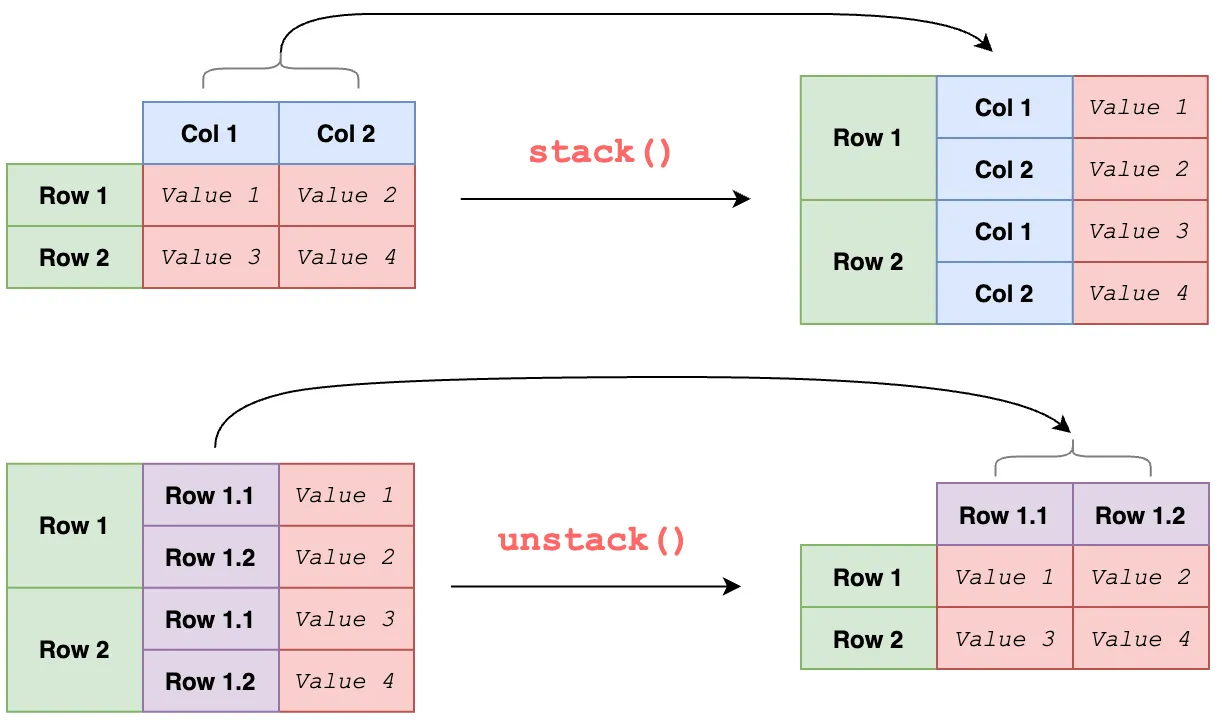

- 아래의 예를 보자.

In [163]:
data = pd.DataFrame(np.arange(6).reshape((2, 3)),
                    index=pd.Index(["Ohio", "Colorado"], name="state"),
                    columns=pd.Index(["one", "two", "three"],
                    name="number"))
data

number,one,two,three
state,,,
Ohio,0,1,2
Colorado,3,4,5


- stack 메서드를 활용하면 행/열의 인덱스가 계층적 색인으로 전환됨

In [164]:
result = data.stack()
result

state     number
Ohio      one       0
          two       1
          three     2
Colorado  one       3
          two       4
          three     5
dtype: int32

- unstack은 stack의 반대 연산

In [165]:
result.unstack()

number,one,two,three
state,,,
Ohio,0,1,2
Colorado,3,4,5


- 기본값으로 가장 하위에 있는 색인을 column으로 사용, but “level” 옵셥을 통해 순서를 지정할 수 있음

In [166]:
result.unstack(level=0)

state,Ohio,Colorado
number,,
one,0,3
two,1,4
three,2,5


- 단계별로 존재하는 하위 그룹의 인덱스가 완전히 동일하지 않을 수 있음.
- 이경우에도 unstack을 수행할 수 있으며, 자연스럽게 결측치가 발생.

In [167]:
s1 = pd.Series([0, 1, 2, 3], index=["a", "b", "c", "d"], dtype="Int64")
s2 = pd.Series([4, 5, 6], index=["c", "d", "e"], dtype="Int64")
data2 = pd.concat([s1, s2], keys=["one", "two"])
data2

data2.unstack()

,a,b,c,d,e
one,0,1,2,3,<NA>
two,<NA>,<NA>,4,5,6


- 결측치가 있는 경우에, stack을 수행하면 결측값은 삭제함.

In [168]:
data2.unstack().stack()

one  a    0
     b    1
     c    2
     d    3
two  c    4
     d    5
     e    6
dtype: Int64

- 결측치를 그대로 유지하려면 dropna 옵션을 활용함

In [169]:
data2.unstack().stack(dropna=False)

C:\Users\jjw94\AppData\Local\Temp\ipykernel_2196\3936770077.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  data2.unstack().stack(dropna=False)


one  a       0
     b       1
     c       2
     d       3
     e    <NA>
two  a    <NA>
     b    <NA>
     c       4
     d       5
     e       6
dtype: Int64

### Pivot / Melt

- 데이터 표현의 형태
    - long-format
    - wide-format

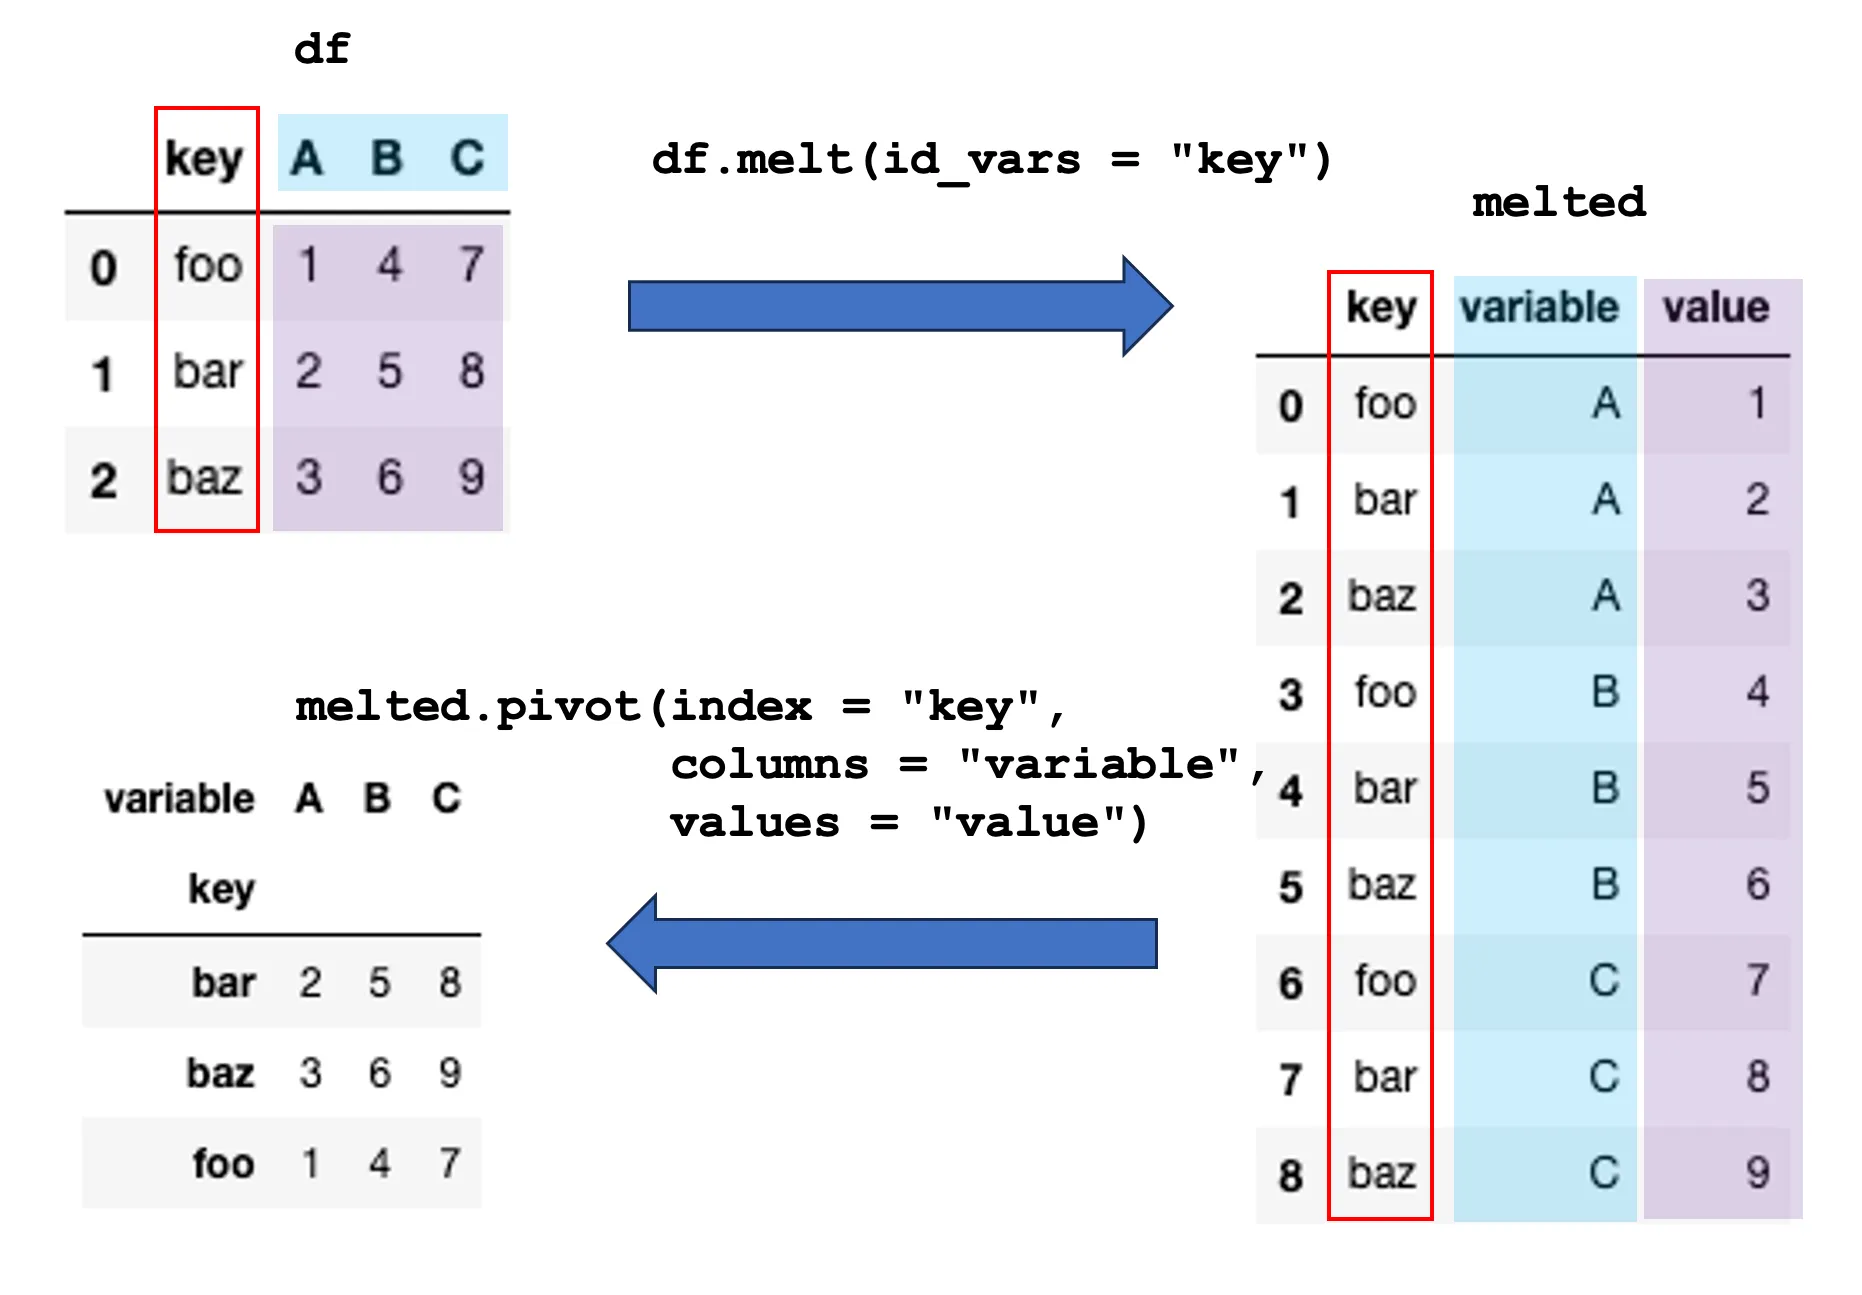

- **Melt: Wide-to-Long**

In [170]:
# Wideform
df = pd.DataFrame({"key": ["foo", "bar", "baz"],
                   "A": [1, 2, 3],
                   "B": [4, 5, 6],
                   "C": [7, 8, 9]})
df

,key,A,B,C
0,foo,1,4,7
1,bar,2,5,8
2,baz,3,6,9


- Key 열을 그룹 id로 사용하고 나머지 데이터 전체의 변수명을 하나의 변수값, 값을 또다른 변수값으로  사용

In [172]:
melted = df.melt(id_vars = "key")
melted

,key,variable,value
0,foo,A,1
1,bar,A,2
2,baz,A,3
3,foo,B,4
4,bar,B,5
5,baz,B,6
6,foo,C,7
7,bar,C,8
8,baz,C,9


- 전체가 아닌 일부를 사용할 수 있음 (value_vars)

In [173]:
df.melt(id_vars="key", value_vars=["A", "B"])

,key,variable,value
0,foo,A,1
1,bar,A,2
2,baz,A,3
3,foo,B,4
4,bar,B,5
5,baz,B,6


- 그룹구분자 없이도 사용 가능

In [174]:
df.melt(value_vars=["A", "B", "C"])
df.melt(value_vars=["key", "A", "B"])

,variable,value
0,key,foo
1,key,bar
2,key,baz
3,A,1
4,A,2
5,A,3
6,B,4
7,B,5
8,B,6


- **pivot: Long-to-wide**

In [175]:
reshaped = melted.pivot(index="key", columns="variable",
                        values="value")
reshaped
reshaped.reset_index() # 인덱스 조정

variable,key,A,B,C
0,bar,2,5,8
1,baz,3,6,9
2,foo,1,4,7
